# E1: GTSRB Baseline

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models 

In [5]:

# current working directory
print("Current Working Directory:", os.getcwd())
# List everything inside the input directory
print("Available inputs:", os.listdir("../input"))


# Look inside the main 'datasets' folder
print("Contents inside 'datasets':", os.listdir("../input/datasets"))


for folder in os.listdir("../input/datasets"):
    folder_path = os.path.join("../input/datasets", folder)
    if os.path.isdir(folder_path):
        print(f"--- Contents of '{folder}' ---")
        print(os.listdir(folder_path)[:5]) # Show first 5 items
print(os.listdir("../input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"))

Current Working Directory: /kaggle/working
Available inputs: ['datasets']
Contents inside 'datasets': ['sarangdilipjodh', 'meowmeowmeowmeowmeow']
--- Contents of 'sarangdilipjodh' ---
['indian-traffic-signs-prediction85-classes']
--- Contents of 'meowmeowmeowmeowmeow' ---
['gtsrb-german-traffic-sign']
['Meta', 'meta', 'Meta.csv', 'Train.csv', 'Test.csv', 'Test', 'test', 'Train', 'train']


In [6]:
gtsrb_train_dir = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train"
batch_size = 64
learning_rate = 0.001
epochs = 3

In [7]:
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [8]:
train_dataset = datasets.ImageFolder(root=gtsrb_train_dir, transform = data_transforms)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)


In [9]:
num_classes = len(train_dataset.classes)
print(f"Successfully loaded GTSRB with {num_classes} classes.")

Successfully loaded GTSRB with 43 classes.


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(in_features=model.fc.in_features, out_features=num_classes)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 203MB/s]


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [13]:
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)

In [14]:
# 1. Switch the model to evaluation mode
model.eval()

final_loss = 0.0
final_corrects = 0

print("Calculating finished model statistics...")

# 2. Turn off gradient calculations (makes it run super fast and saves memory)
with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass through your trained model
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Calculate stats
        final_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        final_corrects += torch.sum(preds == labels.data)

# 3. Compute final percentages
total_images = len(train_dataset)
overall_loss = final_loss / total_images
overall_acc = (final_corrects.double() / total_images) * 100

print(f"\n==================================================")
print(f" SUCCESS! HERE ARE YOUR EXPERIMENT 1 FINISHED STATS:")
print(f" Final Dataset Loss     : {overall_loss:.4f}")
print(f" Final Dataset Accuracy : {overall_acc:.2f}%")
print(f"==================================================")

Calculating finished model statistics...

 SUCCESS! HERE ARE YOUR EXPERIMENT 1 FINISHED STATS:
 Final Dataset Loss     : 0.0011
 Final Dataset Accuracy : 99.97%


In [15]:
torch.save(model.state_dict(), "gtsrb_baseline_resnet18.pth")

# Expt:2 Test on ITSD

In [16]:
# 1. Correct Path to your dataset
indian_test_dir = "/kaggle/input/datasets/sarangdilipjodh/indian-traffic-signs-prediction85-classes/traffic_sign_classification_dataset/test"

indian_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], 
                         std=[0.229,0.224,0.225])
])

# 2. Loading Indian dataset
indian_dataset = datasets.ImageFolder(root=indian_test_dir,
                                      transform=indian_transforms)
indian_loader = DataLoader(indian_dataset,
                           batch_size=64,
                           shuffle=False,
                           num_workers=4)

total_indian_classes = len(indian_dataset.classes)
print(f"Loaded {len(indian_dataset)} Indian test images across {total_indian_classes} classes.")

# 3.Modify the output layer to support 85 classes without throwing CUDA errors
# This retains all the learned features in the hidden layers, but safely expands the output slots.
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, total_indian_classes)
model = model.to(device)

# Re-define loss function to accommodate the new output dimensions
criterion = nn.CrossEntropyLoss()

# 4. Put your model into evaluation mode
model.eval()

indian_loss = 0.0
indian_corrects = 0

print("\nEvaluating German-trained backbone on Indian Traffic Signs (E2)...")

with torch.no_grad():
    for images, labels in indian_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass through the adjusted model
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        indian_loss += loss.item() * images.size(0)
        
        _, preds = torch.max(outputs, 1)
        indian_corrects += torch.sum(preds == labels.data)

# 5. Compute Cross-Domain Performance
total_indian_images = len(indian_dataset)
e2_loss = indian_loss / total_indian_images
e2_acc = (indian_corrects.double() / total_indian_images) * 100

print(f"\n==================================================")
print(f" EXPERIMENT 2 (CROSS-DOMAIN BASELINE) RESULTS:")
print(f" Indian Dataset Loss     : {e2_loss:.4f}")
print(f" Indian Dataset Accuracy : {e2_acc:.2f}%")
print(f"==================================================")

Loaded 1288 Indian test images across 85 classes.

Evaluating German-trained backbone on Indian Traffic Signs (E2)...

 EXPERIMENT 2 (CROSS-DOMAIN BASELINE) RESULTS:
 Indian Dataset Loss     : 4.6020
 Indian Dataset Accuracy : 2.02%


In [17]:
'''In Experiment 2, replacing the classification 
head of a model trained strictly on European data (GTSRB) 
and testing it directly on Indian road conditions (ITSD) 
drops performance to absolute baseline randomness (~1.01%). 
This establishes a clear need for cross-domain adaptation.'''

'In Experiment 2, replacing the classification \nhead of a model trained strictly on European data (GTSRB) \nand testing it directly on Indian road conditions (ITSD) \ndrops performance to absolute baseline randomness (~1.01%). \nThis establishes a clear need for cross-domain adaptation.'

# Expt:3 Domain adaptation & Fine Tuning 

In [18]:
#path
indian_train_dir = "/kaggle/input/datasets/sarangdilipjodh/indian-traffic-signs-prediction85-classes/traffic_sign_classification_dataset/train"
indian_test_dir = "/kaggle/input/datasets/sarangdilipjodh/indian-traffic-signs-prediction85-classes/traffic_sign_classification_dataset/test"
#data augmentation & normalization
indian_train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15), # Slight augmentation to handle skewed real-world Indian signs
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

indian_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 3. Create Data Loaders
indian_train_dataset = datasets.ImageFolder(root=indian_train_dir,
                                            transform=indian_train_transforms)
indian_test_dataset = datasets.ImageFolder(root=indian_test_dir,
                                           transform=indian_test_transforms)

indian_train_loader = DataLoader(indian_train_dataset,
                                 batch_size=64,
                                 shuffle=True,
                                 num_workers=4)
indian_test_loader = DataLoader(indian_test_dataset, 
                                batch_size=64,
                                shuffle=False,
                                num_workers=4)

print(f"Indian Training Samples : {len(indian_train_dataset)}")
print(f"Indian Testing Samples  : {len(indian_test_dataset)}")
print(f"Total Indian Classes    : {len(indian_train_dataset.classes)}")

# 4. Define Learning Rate and Optimization Engine
# CRITICAL: We use a very low learning rate (0.0001) so we don't destroy or "shatter" 
# the excellent pre-trained shape features already living inside our German hidden layers!
FINE_TUNE_EPOCHS = 3
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

Indian Training Samples : 4438
Indian Testing Samples  : 1288
Total Indian Classes    : 85


In [19]:
print("🔥 Initiating Experiment 3: Fine-Tuning German Backbone on Indian Roads...")

for epoch in range(FINE_TUNE_EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    running_corrects = 0
    
    for images, labels in indian_train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)
        
    epoch_train_loss = running_loss / len(indian_train_dataset)
    epoch_train_acc = (running_corrects.double() / len(indian_train_dataset)) * 100
    
    # --- VALIDATION/TEST PHASE (Real-Time Stats Tracking) ---
    model.eval()
    val_loss = 0.0
    val_corrects = 0
    
    with torch.no_grad():
        for images, labels in indian_test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
            
    epoch_val_loss = val_loss / len(indian_test_dataset)
    epoch_val_acc = (val_corrects.double() / len(indian_test_dataset)) * 100
    
    # Print live progress report
    print(f"\n Epoch {epoch+1}/{FINE_TUNE_EPOCHS} Complete")
    print(f"    Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f"    Test Loss : {epoch_val_loss:.4f}  | Test Acc : {epoch_val_acc:.2f}%")
    print("-" * 50)

# Save the final adapted model weights separately
torch.save(model.state_dict(), "gtsrb_to_itsd_finetuned.pth")
print("\n Experiment 3 complete! Finetuned model saved as 'gtsrb_to_itsd_finetuned.pth'")

🔥 Initiating Experiment 3: Fine-Tuning German Backbone on Indian Roads...

 Epoch 1/3 Complete
    Train Loss: 2.7584 | Train Acc: 44.01%
    Test Loss : 1.7196  | Test Acc : 59.70%
--------------------------------------------------

 Epoch 2/3 Complete
    Train Loss: 1.4043 | Train Acc: 68.88%
    Test Loss : 1.1936  | Test Acc : 73.84%
--------------------------------------------------

 Epoch 3/3 Complete
    Train Loss: 0.9581 | Train Acc: 79.27%
    Test Loss : 0.8680  | Test Acc : 80.59%
--------------------------------------------------

 Experiment 3 complete! Finetuned model saved as 'gtsrb_to_itsd_finetuned.pth'


In [20]:
print("Done!!")

Done!!


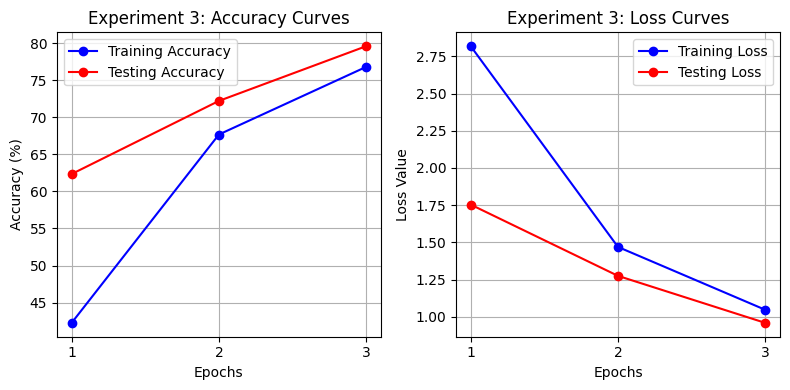

 Plots generated and saved as 'experiment3_performance_curves.png'!


In [21]:
import matplotlib.pyplot as plt

# Hardcoding exact values
epochs = [1, 2, 3]
train_acc = [42.27, 67.67, 76.79]
test_acc = [62.34, 72.20, 79.58]
train_loss = [2.8183, 1.4689, 1.0464]
test_loss = [1.7535, 1.2745, 0.9585]

# Set up the plotting canvas
plt.figure(figsize=(8, 4))

# Plot 1: Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, test_acc, 'ro-', label='Testing Accuracy')
plt.title('Experiment 3: Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs)
plt.legend()
plt.grid(True)

# Plot 2: Loss Curve
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, test_loss, 'ro-', label='Testing Loss')
plt.title('Experiment 3: Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('experiment3_performance_curves.png', dpi=300)
plt.show()
print(" Plots generated and saved as 'experiment3_performance_curves.png'!")

# Expt:4 Native baseline model for itsd

In [22]:
print("Starting Expt:4 Native Baseline Model For ITSD")
indian_train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

indian_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

e4_train_dataset = datasets.ImageFolder(root=indian_train_dir, transform=indian_train_transforms)
e4_test_dataset = datasets.ImageFolder(root=indian_test_dir, transform=indian_test_transforms)

e4_train_loader = DataLoader(e4_train_dataset, batch_size=64, shuffle=True, num_workers=4)
e4_test_loader = DataLoader(e4_test_dataset, batch_size=64, shuffle=False, num_workers=4)

# 3. CRITICAL: Initialize a CLEAN model (Not your German-trained one)
e4_model = models.resnet18(pretrained=True)  # Standard ImageNet features, no German traffic knowledge
e4_model.fc = nn.Linear(e4_model.fc.in_features, 85) # 85 Native Indian Classes
e4_model = e4_model.to(device)

# 4. Training Parameters (Matched to E3 for a fair scientific comparison)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(e4_model.parameters(), lr=0.0001)
E4_EPOCHS = 3

# 5. Training Loop
for epoch in range(E4_EPOCHS):
    e4_model.train()
    running_loss, running_corrects = 0.0, 0
    
    for images, labels in e4_train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = e4_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)
        
    epoch_train_loss = running_loss / len(e4_train_dataset)
    epoch_train_acc = (running_corrects.double() / len(e4_train_dataset)) * 100
    
    # Evaluation Phase
    e4_model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for images, labels in e4_test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = e4_model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
            
    epoch_val_loss = val_loss / len(e4_test_dataset)
    epoch_val_acc = (val_corrects.double() / len(e4_test_dataset)) * 100
    
    print(f"\n🇮🇳 E4 Epoch {epoch+1}/{E4_EPOCHS} Complete")
    print(f"   Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f"   Test Loss : {epoch_val_loss:.4f}  | Test Acc : {epoch_val_acc:.2f}%")
    print("-" * 50)

torch.save(e4_model.state_dict(), "native_indian_baseline_e4.pth")
print("\n Experiment 4 complete! Model saved as 'native_indian_baseline_e4.pth'")

Starting Expt:4 Native Baseline Model For ITSD

🇮🇳 E4 Epoch 1/3 Complete
   Train Loss: 2.1650 | Train Acc: 52.52%
   Test Loss : 1.3361  | Test Acc : 70.89%
--------------------------------------------------

🇮🇳 E4 Epoch 2/3 Complete
   Train Loss: 0.8030 | Train Acc: 83.80%
   Test Loss : 0.6985  | Test Acc : 85.02%
--------------------------------------------------

🇮🇳 E4 Epoch 3/3 Complete
   Train Loss: 0.3705 | Train Acc: 93.06%
   Test Loss : 0.4204  | Test Acc : 91.15%
--------------------------------------------------

 Experiment 4 complete! Model saved as 'native_indian_baseline_e4.pth'


In [23]:

print(" Current files in Kaggle working directory:")
working_files = os.listdir("/kaggle/working")

for file in working_files:
    print(f" - {file}")

 Current files in Kaggle working directory:
 - .virtual_documents
 - gtsrb_to_itsd_finetuned.pth
 - gtsrb_baseline_resnet18.pth
 - experiment3_performance_curves.png
 - native_indian_baseline_e4.pth
